In [1]:
import torch
from torch import nn

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

Get the data ready

In [155]:
from math import nan
import pandas as pd

# model_input_df     = pd.read_csv("model_input_all_traintest.csv")
# immunogenic_df     = pd.read_csv("cedar_imm_peps_traintest.txt", header=None)
# non_immunogenic_df = pd.read_csv("cedar_non_imm_peps_traintest.txt", header=None)

model_input_df     = pd.read_csv("model_input_nn_traintest_9kcleavedself.csv") #"model_input_traintest_randselfpeps_commonAlleles_nomhcnuggs_newPath.csv") #"model_input_traintest_randselfpeps_new_pathogenicity.csv") # model_input_traintest_and_10krandselfpeps_m4.csv
immunogenic_df     = pd.read_csv("cedar_imm_peps_traintest.txt", header=None)
non_immunogenic_df = pd.read_csv("cedar_non_imm_peps_traintest.txt", header=None)

labels_df = pd.DataFrame(columns=['peptide', 'immunogenic'])
labels_df['peptide'] = model_input_df['peptide']

labels_df['immunogenic'] = nan

labels_df.loc[labels_df['peptide'].isin(immunogenic_df[0]), 'immunogenic'] = 1
labels_df.loc[labels_df['peptide'].isin(non_immunogenic_df[0]), 'immunogenic'] = 0

labels_df = labels_df[~labels_df['immunogenic'].isna()]
model_input_df = model_input_df[model_input_df['peptide'].isin(labels_df['peptide'])]

print(model_input_df.shape)
print(labels_df.shape)

(19499, 98)
(19499, 2)


Select only relevant features from model input

In [156]:
model_input_df.columns

Index(['peptide', 'HLA-A01:01_MHCFlurry_%Rank', 'HLA-A02:01_MHCFlurry_%Rank',
       'HLA-A03:01_MHCFlurry_%Rank', 'HLA-A11:01_MHCFlurry_%Rank',
       'HLA-A24:02_MHCFlurry_%Rank', 'HLA-A33:03_MHCFlurry_%Rank',
       'HLA-B15:01_MHCFlurry_%Rank', 'HLA-B35:01_MHCFlurry_%Rank',
       'HLA-B40:01_MHCFlurry_%Rank', 'HLA-B40:02_MHCFlurry_%Rank',
       'HLA-B44:03_MHCFlurry_%Rank', 'HLA-B51:01_MHCFlurry_%Rank',
       'HLA-B52:01_MHCFlurry_%Rank', 'HLA-C01:02_MHCFlurry_%Rank',
       'HLA-C03:03_MHCFlurry_%Rank', 'HLA-C03:04_MHCFlurry_%Rank',
       'HLA-C06:02_MHCFlurry_%Rank', 'HLA-C07:01_MHCFlurry_%Rank',
       'HLA-C07:02_MHCFlurry_%Rank', 'HLA-A01:01_MixMHCpred_%Rank',
       'HLA-A02:01_MixMHCpred_%Rank', 'HLA-A03:01_MixMHCpred_%Rank',
       'HLA-A11:01_MixMHCpred_%Rank', 'HLA-A24:02_MixMHCpred_%Rank',
       'HLA-A33:03_MixMHCpred_%Rank', 'HLA-B15:01_MixMHCpred_%Rank',
       'HLA-B35:01_MixMHCpred_%Rank', 'HLA-B40:01_MixMHCpred_%Rank',
       'HLA-B40:02_MixMHCpred_%Rank', 'HLA

In [157]:
# model_input_df.drop(columns=['best_netmhc_r', 'best_mixmhc_r', 'best_mhcflurry_r', 'best_mhcnuggets_r',
#                              'Num_Tools_Super_Strong_Binder','Num_Tools_Strong_Binder', 'Num_Tools_Weak_Binder',
#                              'Num_Tools_Super_Weak_Binder', 'Num_Tools_0_01', 'Num_Tools_0_02',
#                              'Num_Tools_0_03', 'Num_Tools_0_04','Num_Tools_0_05', 'Num_Tools_1','Num_Tools_2'],
#                     inplace=True, errors='ignore')
model_input_df.drop(columns=['best_netmhc_r', 'best_mixmhc_r', 'best_mhcflurry_r', 'best_mhcnuggets_r',
                             'Num_Tools_Super_Strong_Binder','Num_Tools_Strong_Binder', 'Num_Tools_Weak_Binder',
                             'Num_Tools_Super_Weak_Binder', 'Num_Tools_0_01', 'Num_Tools_0_02',
                             'Num_Tools_0_03', 'Num_Tools_0_04','Num_Tools_0_05', 'Num_Tools_1','Num_Tools_2',
                             'tap_score', 'selfsimilarity', 'best_allele'],
                    inplace=True, errors='ignore')
model_input_df.shape

# Add Length as a feature
model_input_df['length'] = model_input_df['peptide'].str.len()

NUM_FEATURES = model_input_df.shape[1] - 1

Convert Pandas DF to numpy

In [158]:
X = model_input_df.drop(columns=['peptide']).to_numpy()
print(X.shape)
y = labels_df.drop(columns=['peptide']).to_numpy()
y = y.flatten()
print(y.shape)

(19499, 81)
(19499,)


Convert numpy to Tensors

In [159]:
# X = torch.from_numpy(X).type(torch.float)
# y = torch.from_numpy(y).type(torch.float)
# print(X.shape)
# print(y.shape)
# X[:5], y[:5]

Feature Scaling

In [160]:
class TorchStandardScaler:
  def fit(self, x):
    self.mean = x.mean(0, keepdim=True)
    self.std = x.std(0, unbiased=False, keepdim=True)
  def transform(self, x):
    x -= self.mean
    x /= (self.std + 1e-7)
    return x

class TorchRobustScaler:
  def fit(self, x):
    self.median = x.median(0, keepdim=True).values
    q1 = x.quantile(0.25, dim=0, keepdim=True)
    q3 = x.quantile(0.75, dim=0, keepdim=True)
    self.iqr = q3 - q1
    return self
  def transform(self, x):
    x -= self.median
    x /= (self.iqr + 1e-7)
    return x
  def fit_transform(self, x):
    self.fit(x)
    return self.transform(x)

# Example usage
data = torch.tensor([[0, 0], [0, 0], [1, 1], [1, 1]]).float()
foo = TorchStandardScaler()
foo.fit(data)
print(f"mean {foo.mean}, std {foo.std}")
foo.transform(data)

mean tensor([[0.5000, 0.5000]]), std tensor([[0.5000, 0.5000]])


tensor([[-1.0000, -1.0000],
        [-1.0000, -1.0000],
        [ 1.0000,  1.0000],
        [ 1.0000,  1.0000]])

In [161]:
# X_scaled = X.clone()

# scale = TorchRobustScaler()
# scale.fit_transform(X_scaled)
# print(f"Original:\n{X[0]}")
# print(f"Scaled:\n{X_scaled[0]}")

Train Test Split

In [162]:
# Split data into train and test sets
from sklearn.model_selection import train_test_split

# Composite stratification key: class label + exact peptide length
lengths = model_input_df['length'].to_numpy()
strata = pd.Series(y).astype(str) + "_" + pd.Series(lengths).astype(str)

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=42,
                                                    stratify=strata)

# X_scaled_train, X_scaled_test, _, _ = train_test_split(X_scaled,
#                                                     y,
#                                                     test_size=0.2,
#                                                     random_state=42,
#                                                     stratify=strata)

print(f"Original:\n{X_train[0]}")
# print(f"Scaled:\n{X_scaled_train[0]}")

Original:
[62.745      46.225       0.538       1.324      62.745      14.277
 31.643      62.745      99.287      62.745      99.287      62.745
 31.643      46.225       7.147      37.359      14.277      46.225
 46.225      17.669      14.534       0.177       2.852      31.402
 12.599       2.719      28.784      36.273      45.257      47.105
 37.157      11.447      14.539      13.985      27.625      21.965
 35.963      17.986      34.056      20.437       0.231       2.147
 42.          8.046       8.987      45.5        33.75       26.294
 35.25       70.556      54.211      33.714      29.667      29.667
 25.368      22.917      21.947      13.501      20.232       9.729
 27.343      14.354      23.143       0.177       0.31533333  4.
  2.          0.          2.          0.9949      0.85063587  0.9448325
  0.69179064  0.98696434  0.92941781  0.9949      0.89525785  0.212
  0.7364341   0.          9.        ]


Imputation of DeepImmuno values

In [163]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median", add_indicator=False)
X_train_imp = imputer.fit_transform(X_train)
X_test_imp  = imputer.transform(X_test)


Scaling

In [164]:
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()
X_scaled_train = scaler.fit_transform(X_train_imp)
X_scaled_test  = scaler.transform(X_test_imp)

Convert to Tensors

In [165]:
X_scaled_train = torch.from_numpy(X_scaled_train).type(torch.float)
X_scaled_test = torch.from_numpy(X_scaled_test).type(torch.float)
y_train = torch.from_numpy(y_train).type(torch.float)
y_test = torch.from_numpy(y_test).type(torch.float)

Model

In [166]:
# class NeuralNetwork(nn.Module):
#     def __init__(self, input_dim=11, hidden_dims=[512, 512], output_dim=1,
#                  activation=nn.ReLU, dropout=0.0):
#         super().__init__()
#         self.flatten = nn.Flatten()

#         layers = []
#         prev_dim = input_dim
#         for h in hidden_dims:
#             layers.append(nn.Linear(prev_dim, h))
#             layers.append(activation())
#             if dropout > 0:
#                 layers.append(nn.Dropout(dropout))
#             prev_dim = h
#         layers.append(nn.Linear(prev_dim, output_dim))

#         self.linear_relu_stack = nn.Sequential(*layers)

#     def forward(self, x):
#         x = self.flatten(x)
#         return self.linear_relu_stack(x)

class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(NUM_FEATURES, 16),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(16, 16),
            nn.Tanh(),
            nn.Dropout(0.3),
            nn.Linear(16, 16),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(16, 1),
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

model_0 = NeuralNetwork().to(device)
print(model_0)

NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=81, out_features=16, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=16, out_features=16, bias=True)
    (4): Tanh()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=16, out_features=16, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.3, inplace=False)
    (9): Linear(in_features=16, out_features=1, bias=True)
  )
)


Evaluation Metrics

In [167]:
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item() # torch.eq() calculates where two tensors are equal
    acc = (correct / len(y_pred)) * 100
    return acc

def precision_fn(y_true, y_pred):
    tp = ((y_pred == 1) & (y_true == 1)).sum().item()
    fp = ((y_pred == 1) & (y_true != 1)).sum().item()
    if tp + fp == 0:
        return 0.0
    return (tp / (tp + fp)) * 100

def balanced_precision_fn(y_true, y_pred, positive_class=1):
    # Precision for positive class
    tp = ((y_pred == positive_class) & (y_true == positive_class)).sum().item()
    fp = ((y_pred == positive_class) & (y_true != positive_class)).sum().item()
    precision_pos = tp / (tp + fp) if (tp + fp) > 0 else 0.0

    # Precision for negative class
    tn = ((y_pred != positive_class) & (y_true != positive_class)).sum().item()
    fn = ((y_pred != positive_class) & (y_true == positive_class)).sum().item()
    precision_neg = tn / (tn + fn) if (tn + fn) > 0 else 0.0

    return ((precision_pos + precision_neg) / 2) * 100

def recall_fn(y_true, y_pred):
    tp = ((y_pred == 1) & (y_true == 1)).sum().item()
    fn = ((y_pred == 0) & (y_true != 0)).sum().item()
    if tp + fp == 0:
        return 0.0
    return (tp / (tp + fn)) * 100

def balanced_accuracy_fn(y_true, y_pred, positive_class=1):
    # Sensitivity (recall for positive class)
    tp = ((y_pred == positive_class) & (y_true == positive_class)).sum().item()
    fn = ((y_pred != positive_class) & (y_true == positive_class)).sum().item()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0

    # Specificity (recall for negative class)
    tn = ((y_pred != positive_class) & (y_true != positive_class)).sum().item()
    fp = ((y_pred == positive_class) & (y_true != positive_class)).sum().item()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

    return ((sensitivity + specificity) / 2) * 100

In [168]:
torch.manual_seed(42)

epochs = 250
learning_rate = 0.001

loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model_0.parameters(), lr=learning_rate, weight_decay=1e-5) #torch.optim.SGD(model_0.parameters(), lr=learning_rate)
optim_name = "Adam"

torch.manual_seed(42)

# Put data to target device
# X_train, y_train = X_train.to(device), y_train.to(device)
# X_test, y_test = X_test.to(device), y_test.to(device)
X_train, y_train = X_scaled_train.to(device), y_train.to(device)
X_test, y_test = X_scaled_test.to(device), y_test.to(device)

epoch_count = []
train_loss_values = []
test_loss_values = []
train_acc_values = []
test_acc_values = []
train_precision_values = []
test_precision_values = []
train_bal_precision_values = []
test_bal_precision_values = []

# Build training and evaluation loop
for epoch in range(epochs):

    ### Training
    model_0.train()

    # 1. Forward pass (model outputs raw logits)
    y_logits = model_0(X_train).squeeze() # squeeze to remove extra `1` dimensions, this won't work unless model and data are on same device
    y_pred = torch.round(torch.sigmoid(y_logits)) # turn logits -> pred probs -> pred labls

    # 2. Calculate loss/accuracy
    # loss = loss_fn(torch.sigmoid(y_logits), # Using nn.BCELoss you need torch.sigmoid()
    #                y_train)
    loss = loss_fn(y_logits, # Using nn.BCEWithLogitsLoss works with raw logits
                  y_train)
    acc = balanced_accuracy_fn(y_true=y_train,
                      y_pred=y_pred)
    precision = precision_fn(y_true=y_train,
                      y_pred=y_pred)
    bal_precision = balanced_precision_fn(y_true=y_train,
                      y_pred=y_pred)

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Loss backwards
    loss.backward()

    # 5. Optimizer step
    optimizer.step()

    ### Testing
    model_0.eval()
    with torch.inference_mode():
        # 1. Forward pass
        test_logits = model_0(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))
        # 2. Caculate loss/accuracy
        test_loss = loss_fn(test_logits,
                            y_test)
        test_acc = balanced_accuracy_fn(y_true=y_test,
                                y_pred=test_pred)
        test_precision = precision_fn(y_true=y_test,
                                y_pred=test_pred)
        test_bal_precision = balanced_precision_fn(y_true=y_test,
                                y_pred=test_pred)

    epoch_count.append(epoch)
    train_loss_values.append(loss.detach().cpu().numpy())
    test_loss_values.append(test_loss.detach().cpu().numpy())
    train_acc_values.append(acc)
    test_acc_values.append(test_acc)
    train_precision_values.append(precision)
    test_precision_values.append(test_precision)
    train_bal_precision_values.append(bal_precision)
    test_bal_precision_values.append(test_bal_precision)

    # Print out what's happening every 10 epochs
    if epoch % 10 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f}, Balanced Acc: {acc:.2f}%, Precision: {precision:.2f}%, Bal Precision: {bal_precision:.2f}% | "
              f"Test loss: {test_loss:.5f}, Test balanced acc: {test_acc:.2f}%, Test precision: {test_precision:.2f}%, Test bal precision: {test_bal_precision:.2f}%")

Epoch: 0 | Loss: 0.69867, Balanced Acc: 49.30%, Precision: 49.19%, Bal Precision: 47.38% | Test loss: 0.69710, Test balanced acc: 49.82%, Test precision: 49.45%, Test bal precision: 36.26%
Epoch: 10 | Loss: 0.69173, Balanced Acc: 51.95%, Precision: 50.90%, Bal Precision: 52.47% | Test loss: 0.69030, Test balanced acc: 53.44%, Test precision: 52.01%, Test bal precision: 54.04%
Epoch: 20 | Loss: 0.68694, Balanced Acc: 55.12%, Precision: 54.37%, Bal Precision: 55.14% | Test loss: 0.68573, Test balanced acc: 55.23%, Test precision: 55.43%, Test bal precision: 55.30%
Epoch: 30 | Loss: 0.68464, Balanced Acc: 55.78%, Precision: 55.45%, Bal Precision: 55.78% | Test loss: 0.68164, Test balanced acc: 55.99%, Test precision: 56.52%, Test bal precision: 56.11%
Epoch: 40 | Loss: 0.68069, Balanced Acc: 56.89%, Precision: 56.16%, Bal Precision: 56.90% | Test loss: 0.67849, Test balanced acc: 57.46%, Test precision: 57.42%, Test bal precision: 57.48%
Epoch: 50 | Loss: 0.67911, Balanced Acc: 57.42%, Pr

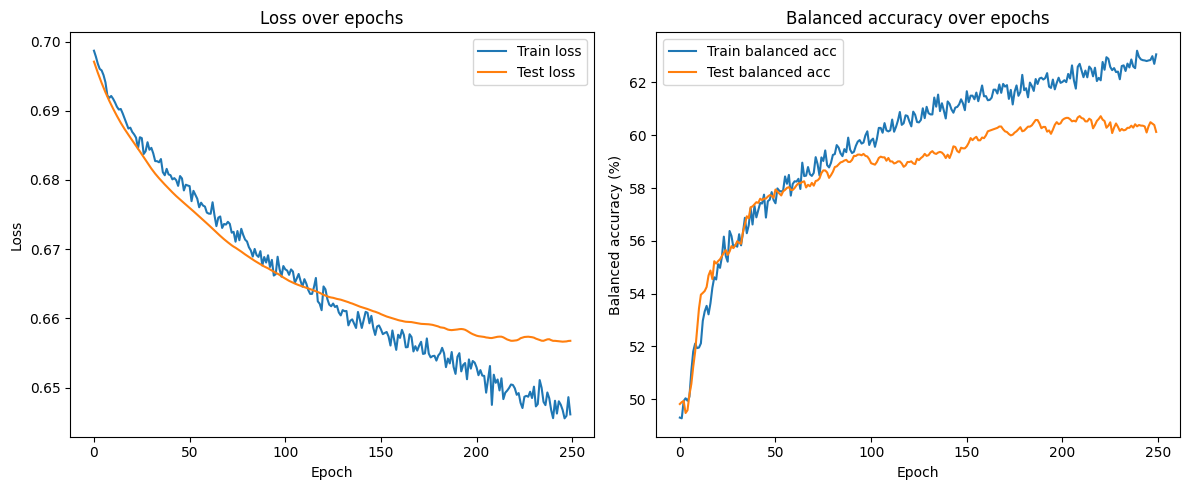

Model Summary:
Immunogenic: 9663 | Non-Immunogenic: 9836
Lr: 0.001
Optimizer: Adam
Loss Fn: BCEWithLogitsLoss()
NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=81, out_features=16, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=16, out_features=16, bias=True)
    (4): Tanh()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=16, out_features=16, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.3, inplace=False)
    (9): Linear(in_features=16, out_features=1, bias=True)
  )
)


In [169]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Loss subplot
ax1.plot(epoch_count, train_loss_values, label="Train loss")
ax1.plot(epoch_count, test_loss_values, label="Test loss")
ax1.set_title("Loss over epochs")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()

# Accuracy subplot
ax2.plot(epoch_count, train_acc_values, label="Train balanced acc")
ax2.plot(epoch_count, test_acc_values, label="Test balanced acc")
ax2.set_title("Balanced accuracy over epochs")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Balanced accuracy (%)")
ax2.legend()

plt.tight_layout()
plt.show()

print("Model Summary:")
print(f"Immunogenic: {labels_df[labels_df['immunogenic'] == 1].shape[0]} | Non-Immunogenic: {labels_df[labels_df['immunogenic'] == 0].shape[0]}")
print(f"Lr: {learning_rate}")
print(f"Optimizer: {optim_name}")
print(f"Loss Fn: {loss_fn}")
print(model_0)

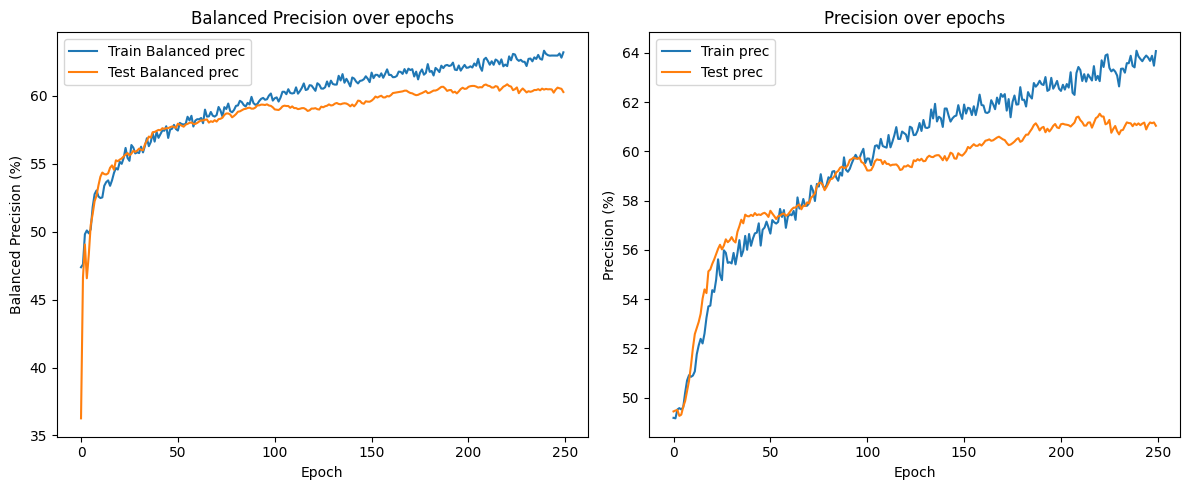

Model Summary:
Immunogenic: 9663 | Non-Immunogenic: 9836
Lr: 0.001
Optimizer: Adam
Loss Fn: BCEWithLogitsLoss()
NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=81, out_features=16, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=16, out_features=16, bias=True)
    (4): Tanh()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=16, out_features=16, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.3, inplace=False)
    (9): Linear(in_features=16, out_features=1, bias=True)
  )
)


In [170]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Loss subplot
ax1.plot(epoch_count, train_bal_precision_values, label="Train Balanced prec")
ax1.plot(epoch_count, test_bal_precision_values, label="Test Balanced prec")
ax1.set_title("Balanced Precision over epochs")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Balanced Precision (%)")
ax1.legend()

# Accuracy subplot
ax2.plot(epoch_count, train_precision_values, label="Train prec")
ax2.plot(epoch_count, test_precision_values, label="Test prec")
ax2.set_title("Precision over epochs")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Precision (%)")
ax2.legend()

plt.tight_layout()
plt.show()

print("Model Summary:")
print(f"Immunogenic: {labels_df[labels_df['immunogenic'] == 1].shape[0]} | Non-Immunogenic: {labels_df[labels_df['immunogenic'] == 0].shape[0]}")
print(f"Lr: {learning_rate}")
print(f"Optimizer: {optim_name}")
print(f"Loss Fn: {loss_fn}")
print(model_0)